# The Quantum Approximate Optimization Algorithm (QAOA) — an interactive lecture

**Who this is for.** Complete beginners. You need basic Python and some comfort with probability and vectors. You do *not* need to know quantum computing, graph theory or optimization: Part 0 teaches the quantum you need, and everything else is built up as we go. By the end you will be able to take **your own** optimization problem, turn it into a QAOA circuit and run it — the goal is to get you ready for a hackathon.

**How to use it.** Run the cells from top to bottom. Wherever you see sliders, **play with them** — that's where the intuition comes from.

**The plan**

| Part | Topic | Quantum? |
|---|---|---|
| 0 | Quantum computing from zero: qubits, gates, interference, measurement | yes |
| 1 | A hard problem: Max-Cut on a graph | no |
| 2 | Turning the problem into a Hamiltonian (spins and $Z$ operators) | a little |
| 3 | The QAOA circuit: *cost layer* + *mixer layer* (Qiskit) | yes |
| 4 | The $p=1$ landscape and running the optimizer | yes |
| 5 | More layers ($p=1,2,3,4$), shots, and a smart starting point | yes |
| 6 | **Your own problem:** QUBO → Ising → QAOA toolkit, constraints as penalties | yes |
| 7 | **Hackathon playbook:** project plan, pitfalls checklist, going further | — |

**The one-sentence version of QAOA:**
> *Start in an equal superposition of all answers. Alternate between "give each answer a phase that depends on how good it is" and "mix the answers together". Tune the two kinds of knobs (angles $\gamma,\beta$) with a normal computer so that, when you measure, good answers are likely.*

**QAOA vs VQE in one line.** VQE hunts for the lowest energy of a *physical* Hamiltonian with a *generic* ansatz. QAOA hunts for the best answer to a *classical* optimization problem with an ansatz whose shape is *dictated by the problem itself*.

In [1]:
# If something is missing, this installs it (Colab usually needs qiskit):
try:
    import qiskit, pylatexenc
except ImportError:
    get_ipython().run_line_magic("pip", "install numpy scipy matplotlib ipywidgets pylatexenc qiskit")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import minimize
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Checkbox, Dropdown

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "font.size": 11})
BLUE, ORANGE, GREEN, RED, GRAY = "#2a6fdb", "#f28c28", "#2e9e5b", "#d64545", "#777777"
print("Ready.")

Ready.


---
# Part 0 · Quantum computing from zero (20 minutes)

If you already know what a qubit, a gate and a measurement are, skip to Part 1. Otherwise this part gives you **exactly** the quantum you need for QAOA — nothing more.

## 0.1 A qubit

A normal bit is 0 or 1. A **qubit** is described by two numbers (*amplitudes*) $a,b$:

$$|\psi\rangle=a\,|0\rangle+b\,|1\rangle,\qquad |a|^2+|b|^2=1 .$$

You can never read $a$ and $b$ directly. When you **measure**, you get 0 with probability $|a|^2$ and 1 with probability $|b|^2$, and the qubit becomes the bit you saw. The state with $a=b=1/\sqrt2$ is a 50/50 coin flip; we call it $|+\rangle$. Use the slider to rotate the qubit with an $R_Y$ gate and see how the probabilities change.

In [2]:
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def show_circuit(qc, **kw):
    # Draw a circuit nicely (matplotlib drawer if available, plain text otherwise)
    try:
        fig = qc.draw("mpl", **kw); display(fig); plt.close(fig)
    except Exception:
        print(qc.draw("text"))

def show_qubit(angle=0.0):
    qc = QuantumCircuit(1); qc.ry(angle, 0)
    a, b = Statevector(qc).data.real                      # RY gives real amplitudes
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
    ax.bar(["measure 0", "measure 1"], [a**2, b**2], color=[BLUE, ORANGE]); ax.set_ylim(0, 1); ax.set_ylabel("probability")
    ax.set_title(f"|ψ> = {a:+.2f}|0> {b:+.2f}|1>")
    t = np.linspace(0, 2*np.pi, 200)
    ax2.plot(np.cos(t), np.sin(t), color=GRAY, lw=1); ax2.arrow(0, 0, a, b, head_width=0.06, color=RED, length_includes_head=True)
    ax2.set_xlabel("amplitude of |0>"); ax2.set_ylabel("amplitude of |1>"); ax2.set_aspect("equal"); ax2.set_title("the state as an arrow")
    plt.tight_layout(); plt.show()

interact(show_qubit, angle=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0.0, description="RY angle", continuous_update=False));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='RY angle', max=6.2831853071…

## 0.2 Gates, and the most important trick: phase becomes probability

A **gate** is a reversible operation on the amplitudes. We only need five:

* $X$ — swaps $\lvert0\rangle\leftrightarrow\lvert1\rangle$ (a NOT).
* $H$ (Hadamard) — turns $\lvert0\rangle$ into $\lvert+\rangle=\frac{\lvert0\rangle+\lvert1\rangle}{\sqrt2}$ and $\lvert1\rangle$ into $\lvert-\rangle=\frac{\lvert0\rangle-\lvert1\rangle}{\sqrt2}$.
* $Z$ — flips the **sign** of the $\lvert1\rangle$ amplitude (a *phase*).
* $R_Z(\varphi)$ — multiplies the $\lvert1\rangle$ amplitude by a phase $e^{i\varphi}$ (relative to $\lvert0\rangle$). 
* $R_X(\theta)$ — rotates the qubit about the $X$ axis, mixing $\lvert0\rangle$ and $\lvert1\rangle$.

Now the key fact. A **phase is invisible to a measurement**: $|+\rangle$ and $|-\rangle$ both give 50/50. But if you apply $H$ *again*, the phase gets converted into a probability:

* $H\,|+\rangle=|0\rangle$ (always 0) and $H\,|-\rangle=|1\rangle$ (always 1).

This is called **interference**, and it is the whole engine of QAOA: *write the quality of each answer into a phase, then use a second gate to turn phase differences into probability differences.* Try it: start with $H$, apply $R_Z(\varphi)$ (the phase), apply $H$ again, then measure.

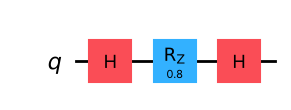

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='phase φ', max=6.28318530717…

In [3]:
def interference(phi=0.0):
    qc = QuantumCircuit(1); qc.h(0); qc.rz(phi, 0); qc.h(0)
    p1 = Statevector(qc).probabilities()[1]
    qc_mid = QuantumCircuit(1); qc_mid.h(0); qc_mid.rz(phi, 0)
    pm = Statevector(qc_mid).probabilities()
    ph = np.linspace(0, 2*np.pi, 200)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
    ax.bar(["0", "1"], pm, color=[BLUE, ORANGE]); ax.set_ylim(0, 1)
    ax.set_title("after H and RZ(φ): 50/50 for any φ\n(the phase is invisible)")
    ax2.plot(ph, np.sin(ph/2)**2, color=BLUE, lw=2); ax2.plot([phi], [p1], "o", ms=12, color=ORANGE)
    ax2.set_xlabel("phase φ"); ax2.set_ylabel("P(measure 1)  after the second H")
    ax2.set_title(f"after the second H: P(1) = sin²(φ/2) = {p1:.2f}")
    plt.tight_layout(); plt.show()

qi = QuantumCircuit(1); qi.h(0); qi.rz(0.8, 0); qi.h(0)       # the three steps: Hadamard, phase, Hadamard
show_circuit(qi)
interact(interference, phi=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0.0, description="phase φ", continuous_update=False));

At $\varphi=0$ you always measure 0; at $\varphi=\pi$ always 1; in between a mixture. **The phase you cannot see directly determines what you will see after the second Hadamard.** In QAOA the "phase" will depend on the *quality of the answer*, and the "second Hadamard" is the mixer.

## 0.3 Several qubits

$n$ qubits have $2^n$ amplitudes, one per bit string. Three qubits already carry 8 numbers; 50 qubits carry about $10^{15}$. A **Hadamard on every qubit** puts all $2^n$ bit strings in equal superposition — every possible answer to a problem is "present" with the same amplitude. Measuring gives one bit string at random.

**Warning — Qiskit's bit order.** Qiskit prints bit strings with qubit 0 on the **right**: `'01'` means qubit 1 is 0 and qubit 0 is 1. We will be careful with this later.

**Entanglement** (the strange part) arises from two-qubit gates, such as the CNOT. The "Bell state" below is a superposition of 00 and 11 only: the two qubits always agree, yet each one individually is random.

X on qubit 0 gives the bit string: 01  (qubit 0 is the RIGHTMOST character)


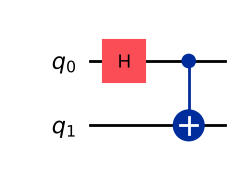

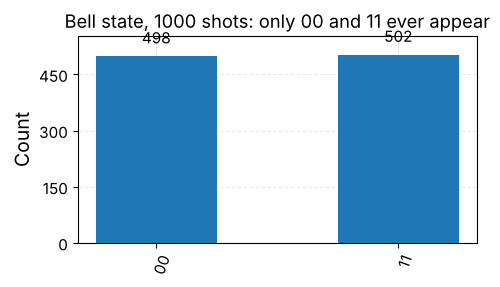

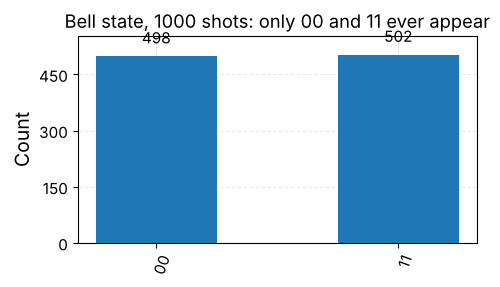

In [4]:
from qiskit.visualization import plot_histogram

qx = QuantumCircuit(2); qx.x(0)                              # flip qubit 0 only
print("X on qubit 0 gives the bit string:", list(Statevector(qx).sample_counts(10).keys())[0], " (qubit 0 is the RIGHTMOST character)")

bell = QuantumCircuit(2); bell.h(0); bell.cx(0, 1)
show_circuit(bell)
display(plot_histogram(Statevector(bell).sample_counts(1000), figsize=(5, 3), title="Bell state, 1000 shots: only 00 and 11 ever appear"))

## 0.4 Observables, Hamiltonians and expectation values

A **measurement of the $Z$ operator** on one qubit returns $+1$ (for bit 0) or $-1$ (for bit 1). On two qubits, $Z_iZ_j$ returns

$$Z_iZ_j=\begin{cases}+1&\text{the two bits are equal}\\-1&\text{the two bits are different.}\end{cases}$$

Keep this sentence in mind — **$Z_iZ_j$ is "do qubits $i$ and $j$ differ?" in disguise**, and that is exactly what Max-Cut asks about an edge.

The **expectation value** $\langle O\rangle$ is the average result of measuring $O$ many times. A **Hamiltonian** $H$ is just an observable written as a sum of such pieces ("Pauli strings" like `ZZ`, `IZ`), for example $H=0.5\,Z_0Z_1$. Its *ground state* is the state with the lowest $\langle H\rangle$. In Qiskit:

In [5]:
from qiskit.quantum_info import SparsePauliOp, Pauli

H_demo = SparsePauliOp.from_list([("ZZ", 0.5)])                # 0.5 * Z_1 Z_0   (strings: qubit 1 on the left)
q00 = QuantumCircuit(2)
q01 = QuantumCircuit(2); q01.x(0)
for name, circ in [("|00>", q00), ("|01>", q01), ("Bell", bell)]:
    sv = Statevector(circ)
    shots = sv.sample_counts(2000)
    est = sum(c * (1 if s[0] == s[1] else -1) for s, c in shots.items()) / 2000      # average of the +-1 outcomes
    print(f"{name:5s}  <ZZ> exact = {sv.expectation_value(Pauli('ZZ')).real:+.2f}   from 2000 shots = {est:+.2f}   <H> = {sv.expectation_value(H_demo).real:+.2f}")

|00>   <ZZ> exact = +1.00   from 2000 shots = +1.00   <H> = +0.50
|01>   <ZZ> exact = -1.00   from 2000 shots = -1.00   <H> = -0.50
Bell   <ZZ> exact = +1.00   from 2000 shots = +1.00   <H> = +0.50


$|00\rangle$ and Bell are "the bits are equal" states ($\langle ZZ\rangle=+1$); $|01\rangle$ has different bits ($-1$). On a real device you get the right-hand number from shots; a simulator can also give the exact left-hand number. 

That is all the quantum we need:

> **amplitudes → probabilities; gates change amplitudes; phases become probabilities through interference; $Z_iZ_j$ asks "are bits $i$ and $j$ different?"; the expectation value of a Hamiltonian is what the optimizer will minimize.**

On to the problem we want to solve.

---
# Part 1 · A hard problem: Max-Cut

### What is Max-Cut?

You are given a **graph**: dots (called *nodes* or *vertices*) joined by lines (called *edges*). Your job is to colour every node either **blue** or **orange**. An edge is **cut** if its two ends get *different* colours. 

> **Goal:** colour the nodes so that the number of cut edges is as large as possible.

Why care? Max-Cut is the textbook example of a *combinatorial optimization* problem: finding clusters in data, laying out circuits, and splitting up work between two machines all look like it. It is also **NP-hard**: no known classical algorithm solves every instance quickly.

### Bits instead of colours

Write the colouring as a string of bits, one per node: $x=x_0x_1\dots x_{n-1}$ with $x_i\in\{0,1\}$ (0 = blue, 1 = orange). The **cost function** (to *maximize*) is

$$\text{cut}(x)=\sum_{(i,j)\in \text{edges}} \big[\,x_i\neq x_j\,\big].$$

With $n$ nodes there are $2^n$ colourings. That is nothing for $n=6$, and astronomical for $n=300$ — which is why we would like a quantum computer to help.

Our test graph has 6 nodes and 9 edges: two triangles joined by three "rungs" (a *prism*). Try colourings with the slider (it counts through all $2^6=64$ bit strings).

In [6]:
n = 6
edges = [(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3), (0, 3), (1, 4), (2, 5)]
pos = {0: (0.0, 1.0), 1: (-0.87, -0.5), 2: (0.87, -0.5),            # outer triangle
       3: (0.0, 0.45), 4: (-0.4, -0.2), 5: (0.4, -0.2)}              # inner triangle

def bits_of(k, n=n):
    """integer k -> list [x_0, ..., x_{n-1}] with x_i the colour of node i."""
    return [(k >> i) & 1 for i in range(n)]

def cut_of_bits(x):
    return sum(x[i] != x[j] for i, j in edges)

# brute force: evaluate all 2^n colourings (index k <-> bit string with x_i = i-th binary digit of k)
cuts = np.array([cut_of_bits(bits_of(k)) for k in range(2**n)])
MAXCUT = int(cuts.max())
n_opt = int((cuts == MAXCUT).sum())
print(f"{len(edges)} edges, {2**n} colourings.  Best cut = {MAXCUT}, reached by {n_opt} different colourings.")
print(f"A random colouring cuts {cuts.mean():.2f} edges on average  ->  ratio {cuts.mean()/MAXCUT:.3f} of the optimum.")

9 edges, 64 colourings.  Best cut = 7, reached by 6 different colourings.
A random colouring cuts 4.50 edges on average  ->  ratio 0.643 of the optimum.


In [7]:
def draw_graph(ax, x=None, title=None):
    for i, j in edges:
        cut = x is not None and x[i] != x[j]
        ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], color=RED if cut else GRAY,
                lw=3 if cut else 1.6, ls="-" if cut else ":", zorder=1)
    for i in range(n):
        col = GRAY if x is None else (BLUE if x[i] == 0 else ORANGE)
        ax.scatter(*pos[i], s=700, color=col, edgecolor="k", zorder=2)
        ax.text(*pos[i], str(i), ha="center", va="center", color="white", fontsize=13, weight="bold", zorder=3)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-0.9, 1.3); ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)
    if title: ax.set_title(title)

def show_cut(k=0):
    x = bits_of(k)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.3]})
    draw_graph(ax, x, f"colouring {''.join(map(str, x))}  ->  {cut_of_bits(x)} edges cut (red)")
    ax2.bar(range(2**n), cuts, color=[GREEN if c == MAXCUT else BLUE for c in cuts], alpha=0.75)
    ax2.plot([k], [cuts[k]], "o", ms=12, color=ORANGE, zorder=5)
    ax2.set_xlabel("colouring index k (binary digits = x_0 x_1 ...)"); ax2.set_ylabel("edges cut")
    ax2.set_title("all 64 colourings (green = optimal)")
    plt.tight_layout(); plt.show()

interact(show_cut, k=IntSlider(min=0, max=2**n - 1, step=1, value=0, description="colouring", continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='colouring', max=63), Output()),…

Things to notice:

* Colourings come in **mirror pairs**: swapping blue and orange everywhere cuts exactly the same edges (look at $k$ and $63-k$). So every cut value appears an even number of times.
* A random colouring cuts only about half the edges. Finding the best one requires looking *through* the 64 options.
* This is exactly the situation of VQE: a landscape (here a bar chart of 64 values) and a minimum (here a maximum) that we want to find, ideally without checking everything.

---
# Part 2 · From a graph to a Hamiltonian

To use a quantum computer we need the cost function to be an **operator**. The trick is to give every node a *spin*: bit 0 $\leftrightarrow$ $Z=+1$, bit 1 $\leftrightarrow$ $Z=-1$. Then for an edge $(i,j)$

$$\tfrac12\big(1-Z_iZ_j\big)=\begin{cases}0 & x_i=x_j\ \ (\text{same spin: } Z_iZ_j=+1)\\ 1 & x_i\neq x_j\ \ (\text{opposite spins: } Z_iZ_j=-1)\end{cases}$$

so the whole cost function is the operator

$$C=\sum_{(i,j)\in\text{edges}}\tfrac12\big(1-Z_iZ_j\big).$$

$C$ is **diagonal in the computational basis**: $C|x\rangle=\text{cut}(x)\,|x\rangle$. Its eigenvalues *are* the cut values, and the maximum eigenvalue (best cut) belongs to the best colouring.

Quantum chemists like to *minimize* energies, so we define the **cost Hamiltonian** $H_C=-C$. Then

> **Max-Cut = find the ground state of $H_C$** — the same kind of problem VQE solves, but with a very simple, classical-looking $H$ (only $Z$'s!).

Let's build it in Qiskit and check that it reproduces our brute-force table. (Careful: Qiskit puts qubit 0 on the *right* of a bit string, which is exactly how our integer $k$ was defined, so everything lines up.)

In [8]:
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit.visualization import plot_histogram

def show_circuit(qc, **kw):
    try:
        fig = qc.draw("mpl", **kw); display(fig); plt.close(fig)
    except Exception:
        print(qc.draw("text"))

# H_C = sum over edges of ( 0.5 * Z_i Z_j - 0.5 * I )   (= minus the number of cut edges)
terms = [("ZZ", [i, j], 0.5) for i, j in edges]
H_C = SparsePauliOp.from_sparse_list(terms, num_qubits=n) + SparsePauliOp("I" * n, -0.5 * len(edges))
H_C = H_C.simplify()
print(H_C)

# H_C is diagonal: its diagonal should be minus our brute-force table
diag = np.real(np.diag(H_C.to_matrix()))
print("\nH_C diagonal == -cuts for all 64 colourings :", np.allclose(diag, -cuts))
print("Lowest eigenvalue of H_C                    :", diag.min(), "  (so the best cut is", -diag.min(), ")")

SparsePauliOp(['IIIIZZ', 'IIIZZI', 'IIIZIZ', 'IZZIII', 'ZZIIII', 'ZIZIII', 'IIZIIZ', 'IZIIZI', 'ZIIZII', 'IIIIII'],
              coeffs=[ 0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,
  0.5+0.j,  0.5+0.j, -4.5+0.j])

H_C diagonal == -cuts for all 64 colourings : True
Lowest eigenvalue of H_C                    : -7.0   (so the best cut is 7.0 )


So the diagonal of $H_C$ is just our table of cut values (with a minus sign). Notice that we could never do this for a large graph by listing the table — but the *operator* $H_C$ has only one term per edge, so it stays small. 

This is the key point: **the quantum computer never needs the table**. It only needs to know the edges.

---
# Part 3 · The QAOA circuit

## 3.1 The recipe

QAOA with $p$ layers prepares the state

$$|\boldsymbol\gamma,\boldsymbol\beta\rangle=\underbrace{e^{-i\beta_pH_M}\,e^{-i\gamma_pH_C}}_{\text{layer }p}\cdots\underbrace{e^{-i\beta_1H_M}\,e^{-i\gamma_1H_C}}_{\text{layer }1}\;|+\rangle^{\otimes n}$$

and the cost function we hand to the classical optimizer is the same as in VQE:

$$F(\boldsymbol\gamma,\boldsymbol\beta)=\langle\boldsymbol\gamma,\boldsymbol\beta|\,H_C\,|\boldsymbol\gamma,\boldsymbol\beta\rangle=-\ \text{(expected number of cut edges)}.$$

There are three ingredients:

1. **Start:** $|+\rangle^{\otimes n}=\frac{1}{\sqrt{2^n}}\sum_x|x\rangle$. Apply a Hadamard on each qubit. *Every* colouring is present with equal amplitude — all 64 answers "at once". Measuring now would just give a uniformly random colouring.

2. **Cost layer** $e^{-i\gamma H_C}$: because $H_C$ is diagonal this simply multiplies each $|x\rangle$ by the phase $e^{+i\gamma\,\text{cut}(x)}$. Better colourings get *more* phase. For our graph it factorizes into one two-qubit gate per edge, $e^{-i\gamma\frac12Z_iZ_j}=R_{ZZ}(\gamma)$. The **angle $\gamma$** controls how strongly cut value is imprinted.

3. **Mixer layer** $e^{-i\beta H_M}$ with $H_M=\sum_iX_i$: a rotation $R_X(2\beta)$ on every qubit. This is what turns *phase differences* into *probability differences*: it lets amplitude flow between colourings that differ by one flipped node. The **angle $\beta$** controls how much.

A phase on its own is invisible to a measurement, and the mixer alone does nothing useful to $|+\rangle^{\otimes n}$ (it's an eigenstate of $\sum X_i$). Only the **combination** of the two makes some answers constructively interfere and others cancel. 

> **Why does a cost layer + mixer help at all?** The optimal $\gamma,\beta$ make amplitudes of high-cut colourings add up and those of low-cut colourings cancel. As $p\to\infty$, QAOA can mimic *adiabatic* quantum computing (slowly turning $H_M$ into $H_C$) and finds the exact answer; for small $p$ it is an approximation — hence the name.

## 3.2 Building it in Qiskit

Only $2p$ numbers — $p$ values of $\gamma$ and $p$ of $\beta$ — control the whole circuit, no matter how large the graph is. We store them in one parameter vector `t`: the first $p$ entries are the $\gamma$'s, the last $p$ the $\beta$'s.

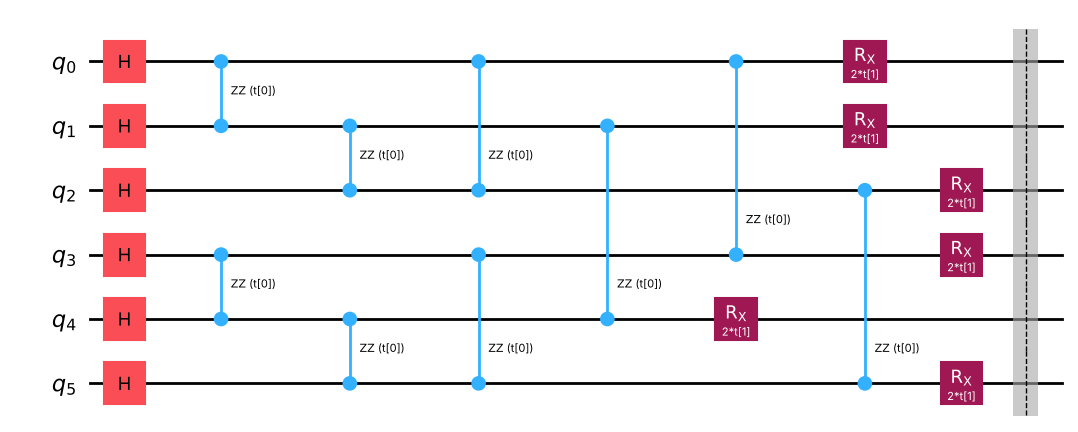

parameters: [ParameterVectorElement(t[0]), ParameterVectorElement(t[1])]


In [9]:
def qaoa_circuit(p):
    """QAOA ansatz with p layers. Parameters: t[0:p] = gammas, t[p:2p] = betas."""
    t = ParameterVector("t", 2 * p)
    qc = QuantumCircuit(n)
    qc.h(range(n))                                  # 1. start in |+>^n
    for layer in range(p):
        gamma, beta = t[layer], t[p + layer]
        for i, j in edges:                          # 2. cost layer: one RZZ per edge
            qc.rzz(gamma, i, j)
        qc.rx(2 * beta, range(n))                   # 3. mixer layer: RX(2 beta) on every qubit
        qc.barrier()
    return qc

qc_p1 = qaoa_circuit(1)
show_circuit(qc_p1, fold=-1)
print("parameters:", list(qc_p1.parameters))

Read the picture left to right: Hadamards (start), nine $R_{ZZ}(\gamma)$ gates (one per edge — you can match them to the `edges` list), then six $R_X(2\beta)$ gates (mixer). That is the **entire** $p=1$ algorithm.

## 3.3 The cost function

Because $H_C$ is diagonal, the energy of any state is just a probability-weighted average of cut values, $\langle H_C\rangle=-\sum_x|\langle x|\psi\rangle|^2\,\text{cut}(x)$. We will use this fast formula (and double-check it against Qiskit's `Estimator`, the same object we used in VQE).

In [10]:
estimator = StatevectorEstimator()

def final_state(params):
    p = len(params) // 2
    qc = qc_cache.setdefault(p, qaoa_circuit(p))
    return Statevector(qc.assign_parameters(list(params)))
qc_cache = {}

def probs(params):
    return final_state(params).probabilities()            # length 2^n, index k = colouring

def expected_cut(params):
    """<C>: expected number of cut edges for the QAOA state (exact, infinite shots)."""
    return float(probs(params) @ cuts)

# Sanity checks
test = [0.7, 0.3]
est = float(estimator.run([(qc_p1, H_C, test)]).result()[0].data.evs)
print(f"Qiskit Estimator:  <H_C> = {est:+.6f}   ->  expected cut = {-est:.6f}")
print(f"Our fast formula:  expected cut = {expected_cut(test):.6f}")
print(f"With gamma = beta = 0 the state is |+>^n:  expected cut = {expected_cut([0, 0]):.3f}   (= half the edges = {len(edges)/2})")

Qiskit Estimator:  <H_C> = -2.687188   ->  expected cut = 2.687188
Our fast formula:  expected cut = 2.687188
With gamma = beta = 0 the state is |+>^n:  expected cut = 4.500   (= half the edges = 4.5)


At $\gamma=\beta=0$ we recover the uniform superposition, whose expected cut is just the random-guess value 4.5. Everything QAOA achieves is *improvement over 4.5, towards 7*.

## 3.4 Playing with the two knobs

For $p=1$ there are just two knobs, $\gamma$ and $\beta$. Move them and watch what happens to the **probabilities of the 64 colourings** if you measured the final state:

* left: probability of every colouring, green bars are optimal cuts;
* right: probability of getting each *cut value* (0 … 7) after measuring, versus the uniform guess (grey).

In [11]:
def show_qaoa(gamma=0.0, beta=0.0):
    pr = probs([gamma, beta])
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.8, 1]})
    ax.bar(range(2**n), pr, color=[GREEN if c == MAXCUT else BLUE for c in cuts], alpha=0.8)
    ax.axhline(1 / 2**n, color=GRAY, ls="--", lw=1)
    ax.set_xlabel("colouring index k"); ax.set_ylabel("probability")
    ax.set_title(f"measurement probabilities    (γ={gamma:.2f}, β={beta:.2f})")
    vals = np.arange(MAXCUT + 1)
    by_cut = np.array([pr[cuts == v].sum() for v in vals])
    uni = np.array([(cuts == v).mean() for v in vals])
    ax2.bar(vals - 0.2, uni, width=0.4, color=GRAY, alpha=0.6, label="random guess")
    ax2.bar(vals + 0.2, by_cut, width=0.4, color=ORANGE, label="QAOA p=1")
    ax2.set_xlabel("edges cut"); ax2.set_ylabel("probability")
    ax2.set_title(f"expected cut = {pr @ cuts:.2f}   |   P(optimal) = {pr[cuts == MAXCUT].sum():.2f}")
    ax2.legend(); plt.tight_layout(); plt.show()

interact(show_qaoa,
         gamma=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0.0, description="γ", continuous_update=False),
         beta=FloatSlider(min=0, max=np.pi, step=0.05, value=0.0, description="β", continuous_update=False));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='γ', max=6.283185307179586, …

Things to try:

* $\gamma=\beta=0$: flat bars (random guessing).
* Keep $\gamma=0$ and move $\beta$: nothing happens. Without the phase imprint, the mixer has nothing to turn into probability.
* Keep $\beta=0$ and move $\gamma$: also nothing happens to the probabilities! Phases alone are invisible to measurement.
* Now move **both** to something like $\gamma\approx 1$, $\beta\approx 0.4$: the right-hand panel shifts towards high cut values. 

Both angles are *periodic*: $\gamma$ repeats after $2\pi$ (because the cut values are integers), and $\beta$ after $\pi/2$ (a shift by $\pi/2$ just applies $X$ to every qubit, which maps every colouring to its mirror image with the same cut). So we only need to search a finite box; we will draw $\beta\in[0,\pi]$, which shows the pattern twice.

---
# Part 4 · The $p=1$ landscape and running QAOA

## 4.1 The landscape

With two parameters we can do what we did in Part 1 of the VQE lecture: draw the whole cost landscape as a map. Here the height is the **expected number of cut edges** (we *maximize* it, so bright is good).

Best point on the grid: γ=2.55, β=1.22  ->  expected cut 5.937  (optimum 7, random 4.5)


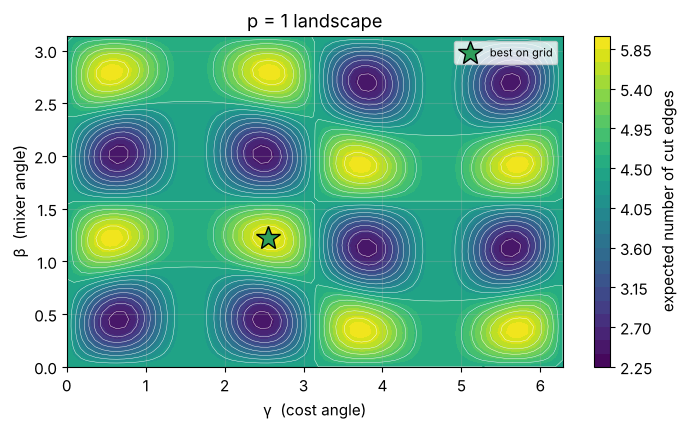

In [12]:
G_N, B_N = 70, 50
gam_grid = np.linspace(0, 2*np.pi, G_N)
bet_grid = np.linspace(0, np.pi, B_N)
GG, BB = np.meshgrid(gam_grid, bet_grid)
land = np.array([[expected_cut([g, b]) for g in gam_grid] for b in bet_grid])

i_b, i_g = np.unravel_index(np.argmax(land), land.shape)
best_grid = (gam_grid[i_g], bet_grid[i_b])
print(f"Best point on the grid: γ={best_grid[0]:.2f}, β={best_grid[1]:.2f}  ->  expected cut {land.max():.3f}  "
      f"(optimum {MAXCUT}, random {cuts.mean():.1f})")

def draw_landscape(ax, path=None, mark=None):
    cs = ax.contourf(GG, BB, land, 30, cmap="viridis")
    ax.contour(GG, BB, land, 15, colors="white", linewidths=0.3)
    ax.plot(*best_grid, "*", ms=18, color=GREEN, mec="k", label="best on grid")
    if path is not None:
        path = np.array(path)
        ax.plot(path[:, 0] % (2*np.pi), path[:, 1] % np.pi, "o", ms=3, color=ORANGE)
        ax.plot(path[0, 0] % (2*np.pi), path[0, 1] % np.pi, "s", ms=11, color="white", mec="k", label="start")
        ax.plot(path[-1, 0] % (2*np.pi), path[-1, 1] % np.pi, "o", ms=11, color=RED, mec="k", label="end")
    if mark is not None:
        ax.plot(*mark, "o", ms=13, color=ORANGE, mec="k")
    ax.set_xlabel("γ  (cost angle)"); ax.set_ylabel("β  (mixer angle)"); ax.legend(loc="upper right", fontsize=8)
    return cs

fig, ax = plt.subplots(figsize=(8, 4.3))
cs = draw_landscape(ax); plt.colorbar(cs, label="expected number of cut edges")
ax.set_title("p = 1 landscape"); plt.show()

Notice:

* There are **several equally good peaks** — the landscape repeats in $\beta$ every $\pi/2$ and is symmetric under $(\gamma,\beta)\to(-\gamma,-\beta)$. Any peak is fine.
* Along the axes $\gamma=0$ and $\beta=0$ the landscape is flat at the random-guess value — exactly what the sliders showed.
* The peak value is well above 4.5 but **below the optimum 7**. One layer is not enough to solve this instance exactly; that is the "approximate" in QAOA. We measure quality by the **approximation ratio** $r=\langle C\rangle/C_{\max}$.

## 4.2 Run the optimizer

Now the VQE loop, unchanged: a classical optimizer (COBYLA, gradient-free, as recommended for quantum hardware) turns the knobs $(\gamma,\beta)$ to maximize the expected cut. Choose a starting point and press the slider; the orange trail shows the optimizer's journey over the landscape.

In [13]:
def run_qaoa(x0, p=None, shots=None, maxiter=200, rhobeg=0.4):
    """Maximize the expected cut with COBYLA.  shots=None -> exact;  shots=int -> estimated from that many samples."""
    history = []
    def cost(params):
        if shots is None:
            val = expected_cut(params)
        else:
            val = sampled_cut(params, shots)
        history.append((*params, val))
        return -val                                   # scipy minimizes, we want to maximize the cut
    res = minimize(cost, x0, method="COBYLA", options={"maxiter": maxiter, "rhobeg": rhobeg})
    return res, np.array(history)

def show_run(g0=1.0, b0=1.5, maxiter=60):
    res, hist = run_qaoa([g0, b0], maxiter=maxiter)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
    draw_landscape(ax, path=hist[:, :2])
    ax.set_title("optimizer path on the p=1 landscape")
    ax2.plot(hist[:, 2], "o-", ms=3, color=ORANGE, label="expected cut")
    ax2.axhline(MAXCUT, color=GREEN, ls="--", label=f"optimal cut = {MAXCUT}")
    ax2.axhline(cuts.mean(), color=GRAY, ls=":", label="random guess")
    ax2.set_xlabel("cost-function evaluation"); ax2.set_ylabel("expected cut"); ax2.legend(loc="center right")
    ax2.set_title(f"final: {-res.fun:.3f}   (ratio {(-res.fun)/MAXCUT:.3f})")
    plt.tight_layout(); plt.show()

interact(show_run,
         g0=FloatSlider(min=0.0, max=2*np.pi, step=0.1, value=1.0, description="start γ", continuous_update=False),
         b0=FloatSlider(min=0.0, max=np.pi, step=0.1, value=1.5, description="start β", continuous_update=False),
         maxiter=IntSlider(min=5, max=100, step=5, value=60, description="max iters", continuous_update=False));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='start γ', max=6.28318530717…

Depending on where you start, the optimizer climbs to one of the peaks (or stalls on a plateau if you start on a flat axis such as $\gamma=0$). All peaks are equally good, so just make sure not to start on the flat lines. In real applications one starts from several random points, or uses a smart guess (see Part 5).

## 4.3 What does the quantum computer actually output?

The optimized circuit does not hand us "the answer". It hands us a **probability distribution over colourings**. We **sample** it, evaluate each sampled colouring on a classical computer (cheap!) and keep the best one seen. That is how QAOA gives a solution.

Take the optimized $p=1$ parameters and sample 1000 shots:

optimized p=1 angles: γ=0.570, β=1.223,  expected cut = 5.939


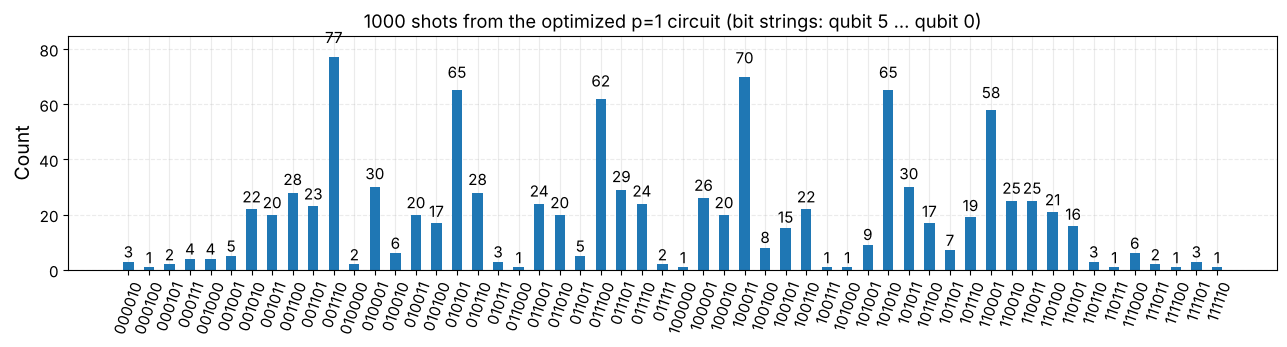

best sampled colouring: 011100  (x_0 ... x_5)  cuts 7 of 9 edges


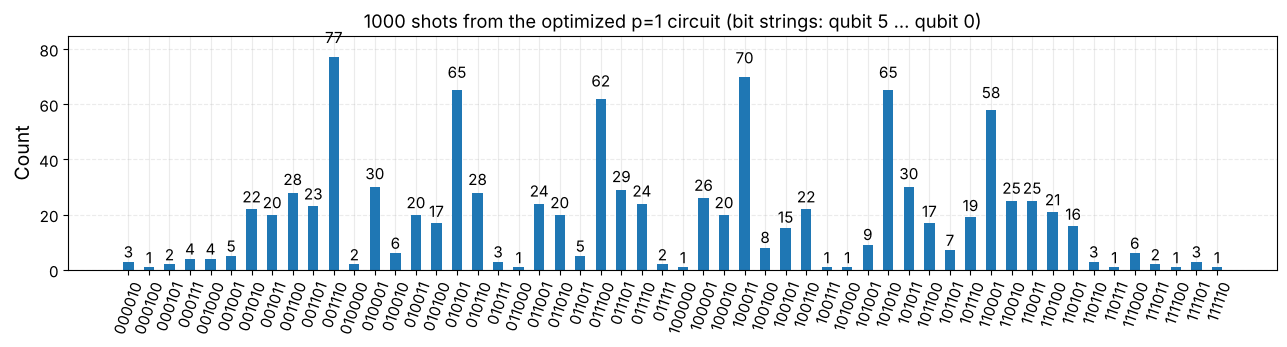

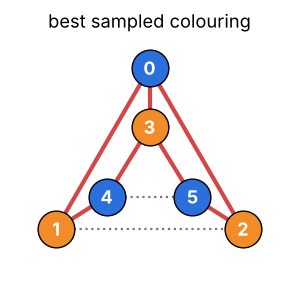

In [14]:
res1, hist1 = run_qaoa([1.0, 1.5], maxiter=150)
params_p1 = res1.x
print(f"optimized p=1 angles: γ={params_p1[0]:.3f}, β={params_p1[1]:.3f},  expected cut = {-res1.fun:.3f}")

sv = final_state(params_p1)
counts = sv.sample_counts(1000, qargs=None)        # dict {bitstring: count}; Qiskit prints qubit n-1 ... qubit 0
display(plot_histogram(counts, figsize=(13, 3.6), title="1000 shots from the optimized p=1 circuit (bit strings: qubit 5 … qubit 0)"))

def cut_of_string(s):
    x = [int(c) for c in s[::-1]]                    # Qiskit string is q_{n-1}...q_0 -> reverse to get x_0 ... x_{n-1}
    return cut_of_bits(x)

best_string = max(counts, key=cut_of_string)
print(f"best sampled colouring: {best_string[::-1]}  (x_0 ... x_5)  cuts {cut_of_string(best_string)} of {len(edges)} edges")
fig, ax = plt.subplots(figsize=(3.6, 3.6)); draw_graph(ax, [int(c) for c in best_string[::-1]], "best sampled colouring"); plt.show()

Even this one-layer circuit finds a colouring that cuts **7 edges** — the true optimum — among 1000 samples, because the optimal colourings are about four times more likely (≈40% per shot) than in a uniform guess (≈9%).

Be careful with the two different goals:

* maximizing the **average** cut (what the optimizer does), and
* finding the **best single** colouring among the samples (what we ultimately want).

The second is easier: you only need to see the optimum *once*.

## 4.4 Realistic measurement noise

On hardware, the energy is not exact; it is estimated by averaging over a finite number of shots. Here we mimic this: each evaluation of the cost function samples `shots` bitstrings from the circuit and averages their cut values (a classical step!). Since $H_C$ is diagonal, **one** measurement setting (all qubits in the $Z$ basis) gives the whole energy — nicer than the molecules in VQE, which needed several settings.

In [15]:
def sampled_cut(params, shots):
    """Average cut of `shots` bitstrings sampled from the QAOA state -- what hardware would give."""
    counts = final_state(params).sample_counts(shots)
    return sum(c * cut_of_string(s) for s, c in counts.items()) / shots

def show_shot_noise(g=1.0, b=0.4, shots=100):
    est = np.array([sampled_cut([g, b], shots) for _ in range(200)])
    ex = expected_cut([g, b])
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(est, bins=30, color=BLUE, alpha=0.75)
    ax.axvline(ex, color="k", ls="--", label=f"exact  {ex:.3f}")
    ax.axvline(est.mean(), color=ORANGE, label=f"mean of estimates  {est.mean():.3f}")
    ax.set_xlabel("estimated expected cut"); ax.set_ylabel("count (200 repeats)")
    ax.set_title(f"{shots} shots per estimate:  spread σ = {est.std():.3f}"); ax.legend(); plt.show()

interact(show_shot_noise,
         g=FloatSlider(min=0, max=2*np.pi, step=0.1, value=1.0, description="γ", continuous_update=False),
         b=FloatSlider(min=0, max=np.pi, step=0.1, value=0.4, description="β", continuous_update=False),
         shots=Dropdown(options=[10, 30, 100, 300, 1000, 10000], value=100, description="shots"));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='γ', max=6.283185307179586),…

The spread shrinks like $1/\sqrt{\text{shots}}$. Now let the optimizer run on these noisy numbers: it jitters, but it still finds the right region. Press **Run**:

In [16]:
def qaoa_noisy(shots=200, g0=1.0, b0=1.5):
    res, hist = run_qaoa([g0, b0], shots=shots, maxiter=60)
    true_val = expected_cut(res.x)                    # the TRUE expected cut of the angles we ended up with
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    draw_landscape(ax, path=hist[:, :2]); ax.set_title("optimizer path with shot noise")
    ax2.plot(hist[:, 2], "o-", ms=3, color=ORANGE, label="noisy estimates")
    ax2.plot([expected_cut(h[:2]) for h in hist], color=BLUE, lw=2, label="true value at those angles")
    ax2.axhline(MAXCUT, color=GREEN, ls="--"); ax2.axhline(cuts.mean(), color=GRAY, ls=":")
    ax2.set_xlabel("evaluation"); ax2.set_ylabel("expected cut"); ax2.legend()
    ax2.set_title(f"true expected cut at the end: {true_val:.3f}"); plt.tight_layout(); plt.show()

interact_manual(qaoa_noisy,
                shots=Dropdown(options=[10, 50, 200, 1000, 5000], value=200, description="shots"),
                g0=FloatSlider(min=0, max=2*np.pi, step=0.1, value=1.0, description="start γ"),
                b0=FloatSlider(min=0, max=np.pi, step=0.1, value=1.5, description="start β"));

interactive(children=(Dropdown(description='shots', index=2, options=(10, 50, 200, 1000, 5000), value=200), Fl…

**Key takeaways of Parts 3–4**

* QAOA = Hadamards, then $p$ times (**cost layer** with angle $\gamma$, **mixer** with angle $\beta$). Only $2p$ numbers.
* The cost layer needs one two-qubit gate per edge, so the circuit stays small even when the table of $2^n$ cut values is astronomically large.
* The classical optimizer tunes $\gamma,\beta$ to maximize the *expected* cut; the final answer comes from *sampling* and keeping the best bit string.
* One layer already beats random guessing clearly but does not reach the optimum on average.

Natural question: what if we add more layers?

---
# Part 5 · More layers, and a smart starting point

## 5.1 Depth $p=1,2,3,4$

Each extra layer adds two more knobs and gives the algorithm more power. The price: a deeper circuit (more noise on real hardware), a higher-dimensional landscape (more local maxima), and more optimizer work. We try $p=1,\dots,4$, each with 10 random starting points, and keep the best run for each $p$. Two figures of merit:

* **approximation ratio** $\langle C\rangle/C_{\max}$ (closer to 1 is better),
* **probability of measuring an optimal colouring** in a single shot.

(This takes about a minute.)

In [17]:
def best_of_restarts(p, n_starts=10, seed=0):
    r = np.random.default_rng(seed + p)
    best = None
    for _ in range(n_starts):
        x0 = np.concatenate([r.uniform(0, 2*np.pi, p), r.uniform(0, np.pi, p)])
        res, _ = run_qaoa(x0, maxiter=400, rhobeg=0.3)
        if best is None or res.fun < best.fun:
            best = res
    return best

results = {}
for p in [1, 2, 3, 4]:
    results[p] = best_of_restarts(p)
    pr = probs(results[p].x)
    print(f"p={p}:  expected cut {-results[p].fun:.3f}   ratio {-results[p].fun/MAXCUT:.3f}   P(optimal) {pr[cuts == MAXCUT].sum():.3f}")
print(f"random guess:  expected cut {cuts.mean():.3f}   ratio {cuts.mean()/MAXCUT:.3f}   P(optimal) {n_opt/2**n:.3f}")

p=1:  expected cut 5.939   ratio 0.848   P(optimal) 0.401


p=2:  expected cut 6.603   ratio 0.943   P(optimal) 0.721


p=3:  expected cut 6.878   ratio 0.983   P(optimal) 0.924


p=4:  expected cut 6.911   ratio 0.987   P(optimal) 0.949
random guess:  expected cut 4.500   ratio 0.643   P(optimal) 0.094


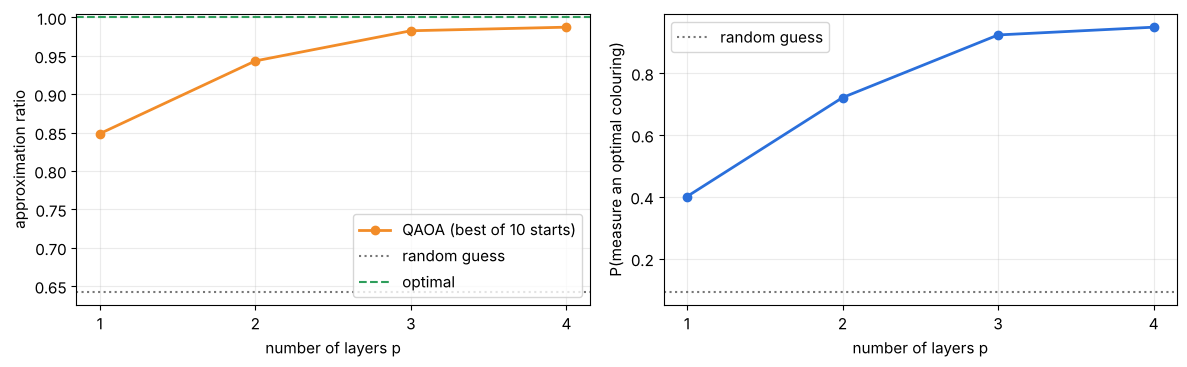

In [18]:
ps = [1, 2, 3, 4]
ratio = [-results[p].fun / MAXCUT for p in ps]
popt = [probs(results[p].x)[cuts == MAXCUT].sum() for p in ps]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax.plot(ps, ratio, "o-", color=ORANGE, lw=2, label="QAOA (best of 10 starts)")
ax.axhline(cuts.mean() / MAXCUT, color=GRAY, ls=":", label="random guess"); ax.axhline(1, color=GREEN, ls="--", label="optimal")
ax.set_xticks(ps); ax.set_xlabel("number of layers p"); ax.set_ylabel("approximation ratio"); ax.legend(loc="lower right")
ax2.plot(ps, popt, "o-", color=BLUE, lw=2); ax2.axhline(n_opt / 2**n, color=GRAY, ls=":", label="random guess")
ax2.set_xticks(ps); ax2.set_xlabel("number of layers p"); ax2.set_ylabel("P(measure an optimal colouring)"); ax2.legend()
plt.tight_layout(); plt.show()

This is the central trade-off of QAOA: **more layers → better answers** (in the noiseless world), converging to the exact solution as $p$ grows. But

* every layer costs $|E|$ two-qubit gates, and today's devices are noisy, so depth is expensive;
* the number of parameters grows, and so does the number of local maxima the optimizer can get trapped in.

You can look at the final distribution for any $p$:

In [19]:
def show_depth(p=2):
    pr = probs(results[p].x)
    fig, ax = plt.subplots(figsize=(13, 3.4))
    ax.bar(range(2**n), pr, color=[GREEN if c == MAXCUT else BLUE for c in cuts], alpha=0.8)
    ax.axhline(1 / 2**n, color=GRAY, ls="--", lw=1)
    ax.set_xlabel("colouring index k"); ax.set_ylabel("probability")
    ax.set_title(f"p={p}: P(optimal)={pr[cuts == MAXCUT].sum():.2f}, expected cut={pr @ cuts:.2f}   (dashed = uniform guess)")
    plt.show()
interact(show_depth, p=IntSlider(min=1, max=4, value=2, description="layers p", continuous_update=False));

interactive(children=(IntSlider(value=2, continuous_update=False, description='layers p', max=4, min=1), Outpu…

## 5.2 Good starting points matter

The landscape for $p=4$ has 8 knobs and many local maxima; random starts often get stuck. A well-known remedy is to start from a **linear ramp** that imitates adiabatic evolution: begin with mostly mixer and end with mostly cost layer,

$$\gamma_k=\frac{k-\tfrac12}{p}\,\Delta,\qquad \beta_k=\Big(1-\frac{k-\tfrac12}{p}\Big)\Delta,\qquad k=1,\dots,p,$$

with some step size $\Delta$ of order 1. (With our sign conventions the useful cost angles are the *negatives* of these, $\gamma_k\to-\gamma_k$; this is allowed by the symmetry $(\gamma,\beta)\to(-\gamma,-\beta)$ we saw in the landscape. Try the opposite sign in the code and watch the starting value fall *below* random guessing!) This needs *no* trial and error with random numbers, and the optimizer then fine-tunes. Let's compare one ramp start to 10 random starts, for $p=4$.

ramp start : [-0.1 -0.3 -0.5 -0.7  0.7  0.5  0.3  0.1]   expected cut before optimizing: 6.367


after COBYLA from the ramp: expected cut 6.881  (ratio 0.983) in 400 evaluations


10 random starts, final expected cuts: [6.14 6.45 6.46 6.48 6.59 6.69 6.78 6.88 6.88 6.95]


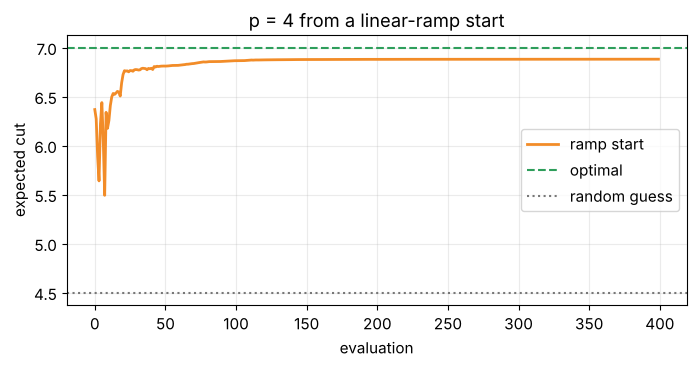

In [20]:
def ramp(p, delta=0.8):
    k = np.arange(1, p + 1)
    return np.concatenate([-(k - 0.5) / p * delta, (1 - (k - 0.5) / p) * delta])   # minus sign: see text

p = 4
x0 = ramp(p)
print("ramp start :", np.round(x0, 3), f"  expected cut before optimizing: {expected_cut(x0):.3f}")
res_r, hist_r = run_qaoa(x0, maxiter=400, rhobeg=0.3)
print(f"after COBYLA from the ramp: expected cut {-res_r.fun:.3f}  (ratio {-res_r.fun/MAXCUT:.3f}) in {len(hist_r)} evaluations")

# individual random starts
rand_final = []
r = np.random.default_rng(123)
for _ in range(10):
    s = np.concatenate([r.uniform(0, 2*np.pi, p), r.uniform(0, np.pi, p)])
    rr, hh = run_qaoa(s, maxiter=400, rhobeg=0.3)
    rand_final.append(-rr.fun)
print("10 random starts, final expected cuts:", np.round(sorted(rand_final), 2))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(hist_r[:, -1], color=ORANGE, lw=2, label="ramp start")
ax.axhline(MAXCUT, color=GREEN, ls="--", label="optimal"); ax.axhline(cuts.mean(), color=GRAY, ls=":", label="random guess")
ax.set_xlabel("evaluation"); ax.set_ylabel("expected cut"); ax.legend(); ax.set_title("p = 4 from a linear-ramp start"); plt.show()

The ramp starts the optimizer already in a good region (expected cut above 4.5 before any optimization), whereas random starts have a wide spread of outcomes (some end noticeably worse than others). On real hardware, where each evaluation costs many shots, a good starting point can save thousands of circuit runs.

## 5.3 How much better than random is "good" when we only take samples?

Remember that what we ultimately report is the **best sampled colouring**. Let's ask: if we are allowed only $S$ shots, how likely is it that at least one of them is an optimal colouring? Compare random sampling with QAOA at $p=1\dots4$.

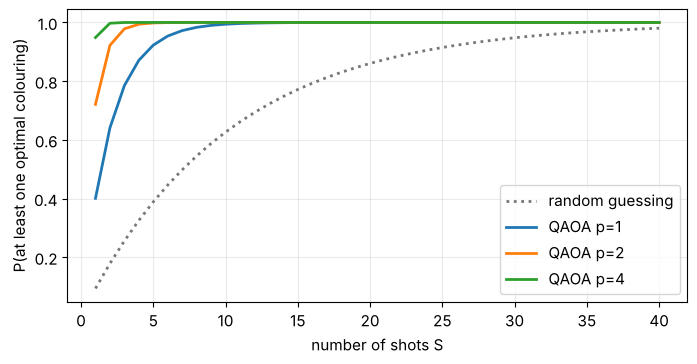

In [21]:
shots_axis = np.arange(1, 41)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(shots_axis, 1 - (1 - n_opt / 2**n) ** shots_axis, color=GRAY, lw=2, ls=":", label="random guessing")
for p in [1, 2, 4]:
    q = probs(results[p].x)[cuts == MAXCUT].sum()
    ax.plot(shots_axis, 1 - (1 - q) ** shots_axis, lw=2, label=f"QAOA p={p}")
ax.set_xlabel("number of shots S"); ax.set_ylabel("P(at least one optimal colouring)"); ax.legend(); plt.show()

For this tiny graph even random guessing succeeds quickly — there are only 64 colourings and a good fraction (6 of 64, nearly 1 in 10) are optimal! The reason to care about QAOA is **scaling**: with $n=100$ nodes the random-guess curve is hopelessly flat, and the hope is that a shallow circuit keeps the probability of success usably large. Whether QAOA actually beats the best classical algorithms for Max-Cut is an **open research question** — in fact, for a 3-regular graph a single layer is guaranteed to cut at least about 69% of the optimum (Farhi, Goldstone & Gutmann, 2014), while a classical algorithm (Goemans–Williamson) guarantees about 88%. Deeper circuits are where the potential lies.

---
# Part 6 · Your own problem: the QUBO toolkit

Max-Cut was one problem. In a hackathon you will want to solve **your** problem. The good news: a huge family of optimization problems can be written in one standard form, and then the *same* QAOA code works for all of them.

## 6.1 The standard form: QUBO

**QUBO** = *Quadratic Unconstrained Binary Optimization*. Choose bits $x_i\in\{0,1\}$ to minimize

$$f(x)=\sum_{i,j}Q_{ij}\,x_ix_j = x^{T}Q\,x .$$

(Because $x_i^2=x_i$, the diagonal $Q_{ii}$ acts as a *linear* term.) $Q$ is just a matrix of numbers. Examples that fit: Max-Cut, picking the best subset of items, scheduling, clustering, portfolio selection, vertex cover, graph colouring.

**QUBO → Ising → QAOA.** Substitute $x_i=\frac{1-z_i}{2}$, where $z_i$ will become the operator $Z_i$ (bit 0 ↔ $z=+1$, bit 1 ↔ $z=-1$). Multiplying out gives a constant plus linear terms plus pair terms,

$$f=\text{const}+\sum_i h_i\,Z_i+\sum_{i<j}J_{ij}\,Z_iZ_j ,$$

which is a Hamiltonian made of $Z$'s: exactly the kind QAOA handles. The cost layer is $e^{-i\gamma H}$, built from one $R_Z(2\gamma h_i)$ per linear term and one $R_{ZZ}(2\gamma J_{ij})$ per pair term (for Max-Cut, $J=\frac12$, which is why we used $R_{ZZ}(\gamma)$).

**Recipe for any problem:**

1. Pick binary variables ("which items are chosen?").
2. Write the quantity to minimize as a quadratic in those variables.
3. Turn every **constraint** into a penalty term that is zero when the constraint holds and positive when it is violated (6.3).
4. Convert to Ising, build the QAOA circuit, optimize $\gamma,\beta$.
5. Sample, **check the constraints classically**, keep the best valid sample.

Below are the four conversion tools. All are short — read them once, then reuse them.

In [22]:
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector

def qubo_to_ising(Q):
    # f(x) = x^T Q x  ->  offset + sum_i h_i z_i + sum_{i<j} J_ij z_i z_j     (x_i = (1 - z_i)/2)
    Q = np.array(Q, float); m = len(Q)
    offset, h, J = 0.0, np.zeros(m), {}
    for i in range(m):
        offset += Q[i, i] / 2;  h[i] -= Q[i, i] / 2                    # Q_ii x_i  = Q_ii (1 - z_i)/2
        for j in range(i + 1, m):
            q = Q[i, j] + Q[j, i]
            if q != 0:                                                 # q x_i x_j = q (1 - z_i - z_j + z_i z_j)/4
                offset += q / 4;  h[i] -= q / 4;  h[j] -= q / 4;  J[(i, j)] = q / 4
    return offset, h, J

def ising_operator(offset, h, J, m):
    terms = [("Z", [i], h[i]) for i in range(m) if h[i] != 0] + [("ZZ", [i, j], v) for (i, j), v in J.items()]
    return (SparsePauliOp.from_sparse_list(terms, num_qubits=m) + SparsePauliOp("I" * m, offset)).simplify()

def all_bitstrings(m):
    # row k = bits (x_0, ..., x_{m-1}) of the integer k  (same convention as Part 1: x_i = i-th binary digit of k)
    return (np.arange(2**m)[:, None] >> np.arange(m)) & 1

def qubo_table(Q):
    X = all_bitstrings(len(Q));  return np.einsum("ki,ij,kj->k", X, np.array(Q, float), X)    # f(x) for every x

def qaoa_general(op, p):
    # QAOA circuit for ANY diagonal Hamiltonian made of Z and ZZ terms.  Parameters: t[0:p] = gammas, t[p:2p] = betas
    m = op.num_qubits;  t = ParameterVector("t", 2 * p)
    qc = QuantumCircuit(m);  qc.h(range(m))
    for l in range(p):
        for pauli, c in zip(op.paulis, op.coeffs):
            idx = [int(i) for i in np.flatnonzero(pauli.z)]
            if len(idx) == 1:   qc.rz(2 * t[l] * c.real, idx[0])
            elif len(idx) == 2: qc.rzz(2 * t[l] * c.real, *idx)
        qc.rx(2 * t[p + l], range(m))
    return qc

# --- Safety check #1: the Ising Hamiltonian must reproduce the QUBO on every bit string
Qtest = np.random.default_rng(1).normal(size=(5, 5))
off, hh, JJ = qubo_to_ising(Qtest)
print("Ising operator reproduces x^T Q x for all 32 bit strings:",
      np.allclose(ising_operator(off, hh, JJ, 5).to_matrix(sparse=True).diagonal().real, qubo_table(Qtest)))

# --- Safety check #2: for Max-Cut the general builder gives the same circuit result as our hand-made one
Q_cut = np.zeros((n, n))
for i, j in edges:                       # maximizing the cut = minimizing -(x_i + x_j - 2 x_i x_j) for every edge
    Q_cut[i, i] -= 1; Q_cut[j, j] -= 1; Q_cut[i, j] += 2
off, hh, JJ = qubo_to_ising(Q_cut)
op_cut = ising_operator(off, hh, JJ, n)
print("Max-Cut as QUBO has the same table as -cuts          :", np.allclose(qubo_table(Q_cut), -cuts))
qc_g = qaoa_general(op_cut, 1)
e_general = float(Statevector(qc_g.assign_parameters([0.7, 0.3])).probabilities() @ qubo_table(Q_cut))
print(f"general QAOA builder, p=1, (γ,β)=(0.7,0.3): <f> = {e_general:.6f}   (Part 3 gave expected cut 2.687188 -> {-e_general:.6f})")

Ising operator reproduces x^T Q x for all 32 bit strings: True
Max-Cut as QUBO has the same table as -cuts          : True
general QAOA builder, p=1, (γ,β)=(0.7,0.3): <f> = -2.687188   (Part 3 gave expected cut 2.687188 -> 2.687188)


Both checks pass: the converter is right, and the general builder reproduces what we derived by hand. **Always run such checks on your own problem** — a sign or index error here silently gives nonsense that *looks* plausible.

Now the solver. It does exactly what Part 4 did, for any $Q$: build the circuit, optimize $\gamma,\beta$ from several random starting points, and return the final probability distribution. (For clarity it uses the exact simulator and a table of all $2^m$ values of $f$ — which only works for small $m$, but the *quantum part* never needs that table; see 7.3 for what to change at scale.)

In [23]:
def solve_qubo(Q, p=2, restarts=8, seed=0):
    Q = np.array(Q, float);  m = len(Q)
    offset, h, J = qubo_to_ising(Q);  op = ising_operator(offset, h, J, m)
    scale = max(np.abs(h).max(), max((abs(v) for v in J.values()), default=0), 1e-9)   # keep angles of order 1
    qc = qaoa_general(op / scale, p)
    f = qubo_table(Q)
    probs = lambda x: Statevector(qc.assign_parameters(list(x))).probabilities()
    energy = lambda x: float(probs(x) @ f)                                              # <f>, what the optimizer minimizes
    r = np.random.default_rng(seed);  best = None
    for _ in range(restarts):
        x0 = np.concatenate([r.uniform(-1, 1, p), r.uniform(0, np.pi / 2, p)])
        res = minimize(energy, x0, method="COBYLA", options={"maxiter": 300, "rhobeg": 0.3})
        if best is None or res.fun < best.fun:
            best = res
    return dict(params=best.x, probs=probs(best.x), f=f, energy=best.fun, circuit=qc, m=m)

def bitstring(k, m):
    return "".join(str((k >> i) & 1) for i in range(m))             # x_0 x_1 ... x_{m-1}

def local_search(Q, restarts=20, seed=0):
    # a simple CLASSICAL baseline: random start, flip the single bit that helps most, repeat until stuck
    Q = np.array(Q, float);  m = len(Q);  r = np.random.default_rng(seed);  best_x, best_f = None, np.inf
    for _ in range(restarts):
        x = r.integers(0, 2, m)
        while True:
            gains = []
            for i in range(m):
                y = x.copy(); y[i] ^= 1; gains.append(y @ Q @ y - x @ Q @ x)
            i = int(np.argmin(gains))
            if gains[i] >= 0: break
            x[i] ^= 1
        if x @ Q @ x < best_f: best_x, best_f = x.copy(), float(x @ Q @ x)
    return best_x, best_f
print("toolkit ready")

toolkit ready


## 6.2 A worked example: choose a team of projects

**The problem.** A company has 6 candidate projects. Project $i$ brings value $v_i$, but some pairs *overlap* (they compete for the same people), which costs us $c_{ij}$ if we pick both. We may fund **exactly $K=3$** projects. Choose them to maximize value minus overlap cost.

* variables: $x_i=1$ if project $i$ is funded;
* objective to minimize: $-\sum_i v_ix_i+\sum_{i<j}c_{ij}x_ix_j$;
* constraint: $\sum_ix_i=K$.

## 6.3 Constraints become penalties

QUBO has no constraints, so we add a **penalty** that is zero when the constraint holds and positive otherwise:

$$A\Big(\sum_ix_i-K\Big)^2 .$$

Multiplying out (using $x_i^2=x_i$): $A\big[(1-2K)\sum_ix_i+2\sum_{i<j}x_ix_j+K^2\big]$, which is again a QUBO. The number $A$ is the **penalty weight**, and choosing it is the single most important practical decision:

* $A$ too small $\Rightarrow$ breaking the rule is cheaper than obeying it, and QAOA happily returns *invalid* answers;
* $A$ huge $\Rightarrow$ the penalty dwarfs the real objective and the landscape becomes rough, so the optimizer finds valid answers but not the best valid one.

A good starting point is $A$ of the same size as the largest value in your objective.

In [24]:
v = np.array([6, 5, 7, 4, 6, 3])                                                           # value of each project
overlap = {(0, 1): 4, (2, 4): 5, (1, 3): 2, (0, 5): 1, (3, 5): 3, (2, 3): 2, (4, 5): 2}   # cost if both are funded
K, M = 3, 6

def project_qubo(A):
    Q = np.zeros((M, M))
    for i in range(M):
        Q[i, i] = -v[i] + A * (1 - 2 * K)                                                   # value + linear part of the penalty
        for j in range(i + 1, M):
            Q[i, j] = overlap.get((i, j), 0) + 2 * A                                        # overlap cost + quadratic part of the penalty
    return Q                                                                                # (the constant A*K^2 does not change the argmin)

# Ground truth by brute force (possible because there are only 64 candidates)
Xb = all_bitstrings(M)
objective = -(Xb @ v) + np.array([sum(c * x[i] * x[j] for (i, j), c in overlap.items()) for x in Xb])   # true objective, ignoring the constraint
feasible = Xb.sum(1) == K
best_val = objective[feasible].min()
optimal = feasible & np.isclose(objective, best_val)
k_star = int(np.flatnonzero(optimal)[0])
print(f"{feasible.sum()} of 64 bit strings are valid (exactly {K} projects).")
print(f"Best valid choice: projects {[i for i in range(M) if Xb[k_star][i]]}  with objective {best_val}   (bit string {bitstring(k_star, M)})")
print(f"Random guessing: P(valid) = {feasible.mean():.2f},  P(optimal) = {optimal.mean():.3f}")

# the classical baseline on the same QUBO
xl, fl = local_search(project_qubo(5.0))
print(f"Classical local search (A=5): {''.join(map(str, xl))}  valid={xl.sum() == K}")

20 of 64 bit strings are valid (exactly 3 projects).
Best valid choice: projects [0, 3, 4]  with objective -16   (bit string 100110)
Random guessing: P(valid) = 0.31,  P(optimal) = 0.016
Classical local search (A=5): 100110  valid=True


Now run QAOA ($p=3$) for several penalty weights and see the trade-off. The table reports, for the final circuit, the probability that a single shot is a **valid** answer and the probability that it is the **best valid** answer. (This runs the optimizer four times; allow ~20 seconds.)

In [25]:
rows = []
sols = {}
for A in [0.5, 2, 5, 20]:
    sol = solve_qubo(project_qubo(A), p=3, restarts=8)
    pr = sol["probs"];  sols[A] = sol
    rows.append((A, pr[feasible].sum(), pr[optimal].sum()))
print(f"{'penalty A':>10s} {'P(valid)':>10s} {'P(optimal)':>11s}  {'P(opt) vs random':>17s}")
for A, pv, po in rows:
    print(f"{A:>10} {pv:>10.2f} {po:>11.3f}  {po / optimal.mean():>14.1f} x")
print(f"{'random':>10s} {feasible.mean():>10.2f} {optimal.mean():>11.3f}")

 penalty A   P(valid)  P(optimal)   P(opt) vs random
       0.5       0.46       0.110             7.0 x
         2       0.80       0.118             7.6 x
         5       0.82       0.156            10.0 x
        20       0.99       0.054             3.5 x
    random       0.31       0.016


Reading the table:

* With a small $A$ (0.5) many shots violate the rule; with large $A$ (20) nearly all shots are valid.
* But the *optimal* valid answer is only found 5–16% of the time: much better than the 1.6% of random guessing, yet far from certain.
* This is normal. QAOA minimizes the **average** $f$ and is a *sampler*: we draw many shots, **throw away invalid ones, and keep the best valid one**. With ~100 shots the chance of seeing the optimum at least once is already close to 100%. Let's do exactly that:

100 shots: 82 valid;  best valid sample = 100110  objective -16   (true optimum -16)
QAOA found the optimum: True


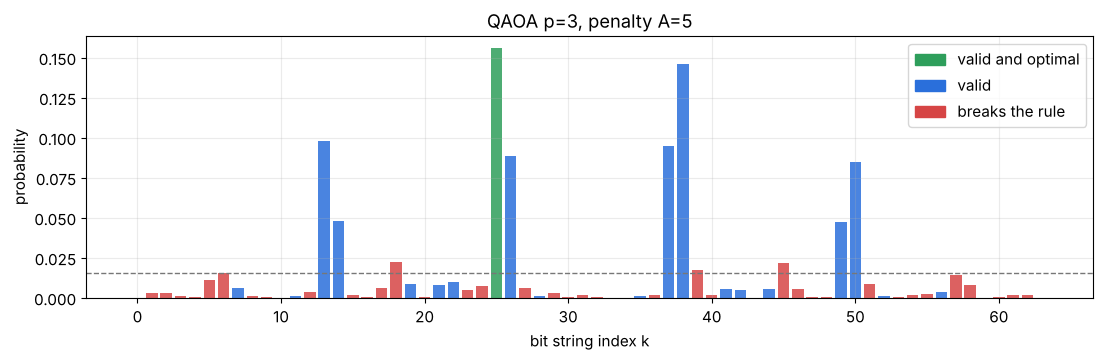

In [26]:
A_best = 5
pr = sols[A_best]["probs"]
shots = 100
sample = np.random.default_rng(0).choice(2**M, size=shots, p=pr / pr.sum())              # what 100 hardware shots would give
valid = [k for k in sample if feasible[k]]
best_k = min(valid, key=lambda k: objective[k])
print(f"{shots} shots: {len(valid)} valid;  best valid sample = {bitstring(best_k, M)}  objective {objective[best_k]}   (true optimum {best_val})")
print("QAOA found the optimum:", bool(optimal[best_k]))

fig, ax = plt.subplots(figsize=(13, 3.4))
cols = [GREEN if optimal[k] else (BLUE if feasible[k] else RED) for k in range(2**M)]
ax.bar(range(2**M), pr, color=cols, alpha=0.85); ax.axhline(1 / 2**M, color=GRAY, ls="--", lw=1)
ax.legend(handles=[Patch(color=GREEN, label="valid and optimal"), Patch(color=BLUE, label="valid"), Patch(color=RED, label="breaks the rule")])
ax.set_xlabel("bit string index k"); ax.set_ylabel("probability"); ax.set_title(f"QAOA p=3, penalty A={A_best}"); plt.show()

That is the full workflow, and you can reuse it unchanged: **write $Q$ → `solve_qubo` → sample → discard invalid → keep the best**. The result is typically as good as simple classical search on a problem this small; the point of the exercise is that the pipeline is the same for problems that are too big to brute-force.

## 6.4 Weighted Max-Cut and other drop-in problems

* **Weighted Max-Cut.** An edge with weight $w$ contributes $w$ to the cut: multiply that edge's terms in `Q_cut` by $w$.
* **Number partitioning** (split numbers $a_i$ into two equal-sum groups): minimize $\big(\sum_ia_iz_i\big)^2$, which is already an Ising model with $J_{ij}=2a_ia_j$.
* **Minimum vertex cover** (pick the fewest nodes that touch every edge): minimize $\sum_ix_i+A\sum_{(i,j)}(1-x_i)(1-x_j)$.
* **Portfolio selection** (choose $K$ assets, maximize return minus risk): the project example with $v_i$ = expected return and $c_{ij}$ = covariance.
* **Graph colouring / scheduling**: one-hot encodings with penalties (a few more variables, same recipe). A catalogue of many problems in QUBO/Ising form is in A. Lucas, *Ising formulations of many NP problems* (2014).

Try one of these yourself with `solve_qubo` before the hackathon starts!

---
# Part 7 · Hackathon playbook

## 7.1 What to build in 24–48 hours

A good QAOA hackathon project has four parts, in this order:

1. **A real problem, small instance.** 6–16 binary variables (qubits) is the sweet spot for simulation. Make the problem *meaningful* (a delivery route, a class timetable, a portfolio, a sensor placement) — judges remember stories.
2. **Correct modelling.** Variables → objective → penalties → QUBO, with the sanity checks from 6.1 (does your Ising operator reproduce the QUBO table? does the brute-force optimum match your expectation?).
3. **QAOA experiments.** Vary $p$, the penalty weight, the optimizer's starting points. Plot approximation ratio and probability of the optimum, like Part 5.
4. **Honest comparison with classical methods.** Brute force (small $n$), `local_search`, simulated annealing, or a solver library. Report where QAOA wins, ties or loses. *Saying "on 12 variables QAOA at $p=3$ matched the classical optimum in X% of shots but needs far more evaluations" is a strong result; claiming quantum advantage is not.*

A realistic 24-hour timeline: **h0–3** choose problem and model it on paper; **h3–8** code the QUBO and check it against brute force; **h8–14** run QAOA for different $p$ and penalties; **h14–20** classical baseline, plots, optional noisy/hardware run; **h20–24** slides, README, demo.

## 7.2 Pitfalls checklist (the bugs everyone hits)

| Symptom | Likely cause |
|---|---|
| Results look random | Qiskit **bit order**: the string is printed qubit $m-1,\dots,0$. We reverse it with `[::-1]` or build bits with `(k >> i) & 1`. Always test on a case where you know the answer. |
| The optimizer maximizes when it should minimize (or the reverse) | Sign of $H$. Qiskit/scipy *minimize*. A "maximize" problem needs a minus sign (we used $H_C=-C$). |
| Optimizer stuck at the random-guess value | Started at $\gamma=0$ or $\beta=0$ (flat directions). Use several random starts or the ramp from 5.2. |
| Answers violate constraints | Penalty $A$ too small. Increase it; also *always* filter samples classically. |
| QAOA finds valid but poor answers | Penalty $A$ too large, or $p$ too small. Reduce $A$, raise $p$. |
| Angles behave strangely when coefficients are big | Normalise the Hamiltonian so the largest coefficient is about 1 (the `scale` line in `solve_qubo`). |
| Simulation is slow / runs out of memory | A state vector needs $16\cdot2^m$ bytes: 20 qubits = 16 MB, 25 = 0.5 GB, 30 = 16 GB. Stay below ~24 qubits on a laptop. |
| Different numbers each run | Sampling is random. Fix seeds (`np.random.default_rng(seed)`) and report averages over several seeds. |

## 7.3 Going further

* **More realistic measurements.** Replace the exact `Statevector` probabilities with sampling (as in 4.4). The cost function becomes noisy, so use gradient-free optimizers (COBYLA, Nelder–Mead) and a few hundred to a few thousand shots per evaluation.
* **Noise.** Qiskit's `qiskit-aer` package can add a noise model to the simulator, so you can show how results degrade with circuit depth — a very good hackathon plot ("QAOA at $p=1$ vs $p=3$ under noise").
* **Real hardware.** IBM Quantum offers free access to real devices through Qiskit's *Runtime* service (you need an account and API token; check the current Qiskit documentation, since the interface changes between releases). Circuits must be *transpiled* to the device's gate set, and expect noise to remove the benefit of deep circuits: use $p\le2$ and small instances.
* **Beyond the basic mixer.** For constraints like "exactly $K$ chosen", problem-specific mixers keep the state inside the valid set so no penalty is needed (search for *QAOA with XY mixer / Dicke state*).
* **Ready-made tools.** Qiskit has companion packages for QAOA and optimization problems (`qiskit-algorithms`, `qiskit-optimization`), and other frameworks (PennyLane, Cirq) implement QAOA too. They are convenient once you understand what is inside — which, after this lecture, you do.

## 7.4 Honest expectations

* QAOA with small $p$ is **not known to beat the best classical algorithms**. Whether it ever will is an open research question. Today it is a learning vehicle and a research direction, so frame your project as an *investigation*.
* Everything you did here is a **simulation** of a quantum computer on a classical machine. That is fine for 6–24 qubits.
* Strong projects: clear modelling, correct checks, careful experiments, honest comparison. Weak projects: huge claims, no baseline.

## 7.5 Where to learn more

* E. Farhi, J. Goldstone, S. Gutmann, *A Quantum Approximate Optimization Algorithm*, arXiv:1411.4028 (2014) — the original paper.
* A. Lucas, *Ising formulations of many NP problems*, arXiv:1302.5843 (2014) — a catalogue of QUBO/Ising models.
* The Qiskit documentation and tutorials (search "Qiskit QAOA tutorial").

---
# Wrap-up

| Idea | Where we saw it |
|---|---|
| Combinatorial optimization: choose the best of $2^n$ bit strings; Max-Cut is a classic example | Part 1 |
| A cost function becomes a diagonal Hamiltonian made of $Z$'s: $H_C=-\sum\tfrac12(1-Z_iZ_j)$ | Part 2 |
| QAOA ansatz: start in the equal superposition, then $p\times$ (cost layer $e^{-i\gamma H_C}$, mixer $e^{-i\beta\sum X}$); only $2p$ parameters | Part 3 |
| Phases alone and mixing alone do nothing; only together do they shift probability towards good answers | Part 3.4 |
| Same loop as VQE: classical optimizer + quantum evaluation; landscape, periodicity, symmetric peaks | Part 4 |
| Output = a *distribution*; we sample, evaluate classically, keep the best | Part 4.3 |
| Shot noise costs $1/\sqrt{\text{shots}}$; one measurement setting suffices because $H_C$ is diagonal | Part 4.4 |
| More layers → better approximation, but deeper circuits, more parameters and more local maxima | Part 5.1 |
| Smart initialization (linear ramp) | Part 5.2 |
| QUBO form; QUBO → Ising → QAOA with `solve_qubo`; constraints as penalties; always sample, filter and keep the best valid answer | Part 6 |
| Hackathon plan, pitfalls checklist, honest comparison with classical baselines | Part 7 |

**Side-by-side with VQE**

| | VQE | QAOA |
|---|---|---|
| Problem | ground-state energy of a molecule | best bit string for a combinatorial problem |
| Hamiltonian | many Pauli terms, $X,Y,Z$ | only $Z$ terms, diagonal |
| Ansatz | chosen from chemistry (e.g. excitations) | dictated by the problem: cost layer + mixer |
| Knobs | as many as the ansatz needs | $2p$ |
| Result | an energy | a distribution; best sample = answer |

**Where to go next.** Try other graphs (change `edges`, `pos`, `n`), weighted edges (put the weights into the $R_{ZZ}$ angles and $H_C$), other problems that are also "Ising models" (number partitioning, vertex cover, scheduling), or run on real hardware by swapping the simulator for an IBM backend.